In [1]:
import os
import h5py
import torch
import psutil
import subprocess
import shutil
import ismrmrd

import numpy as np
import pypulseq as pp
import MRzeroCore as mr0
import matplotlib.pyplot as plt

from seq2xml import seq2xml

running with lxml.etree


/Users/jfelder/miniforge3/envs/torch/lib/python3.10/site-packages/MRzeroCore/phantom/brainweb/__init__.py:12: ResourceWarning: unclosed file <_io.TextIOWrapper name='/Users/jfelder/miniforge3/envs/torch/lib/python3.10/site-packages/MRzeroCore/phantom/brainweb/brainweb_data.json' mode='r' encoding='UTF-8'>
  brainweb_data = json.load(open(brainweb_data_path))


# Create a single FID

In [2]:
# System limits
system = pp.Opts(
    max_grad=28,
    grad_unit="mT/m",
    max_slew=150,
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    # adc_dead_time=0,
    adc_dead_time=20e-6,
    grad_raster_time=50*1e-6
)

In [3]:
# choose the scanner limits
sys = system

# define the sequence
seq = pp.Sequence()

fov             = 200e-3
slice_thickness = 5e-3
alpha           = 70    # flip angle in degree
Nread           = 32    # frequency encoding steps/samples
Nphase          = 1
Npart           = 1
dwell_time  = 10e-5                     # ADC dwell time 
ro_duration = Nread * dwell_time        # ADC duration

# define rf pulse
rf = pp.make_block_pulse(
    flip_angle = alpha * np.pi / 180, 
    duration = 1e-3,
    time_bw_product = 4,
    delay = sys.rf_dead_time,
    system = sys
    )

# define adc event
adc = pp.make_adc(
    num_samples = Nread, 
    duration = ro_duration, 
    phase_offset = 0 * np.pi/180,   # Will add offset in read loop
    delay = sys.adc_dead_time,
    system = sys
)

# set counter
seq.add_block(pp.make_label(label='REV', type='SET', value=1))

# add rf and adc pulse to the sequence
seq.add_block(rf)
seq.add_block(adc)

# set definitions
seq.set_definition('FOV', [fov, fov, slice_thickness])
seq.set_definition('name', 'FID')
seq.set_definition('matrix', [Nread, Nphase, Npart])

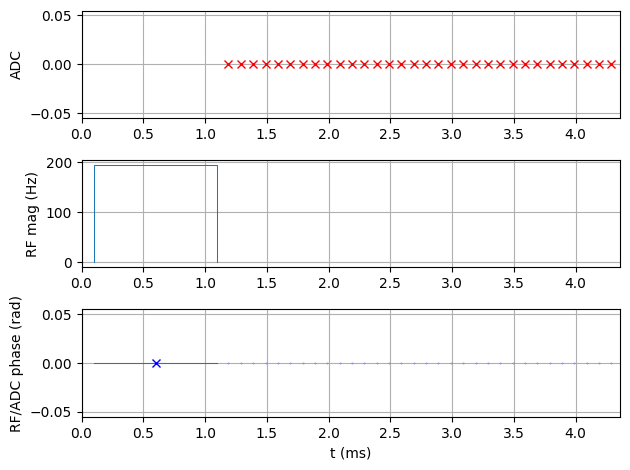

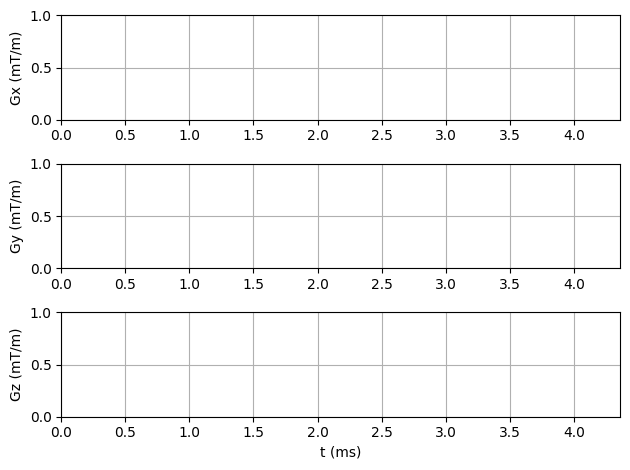

In [4]:
seq.plot(time_range=np.array([0, 5e-3]), time_disp='ms', grad_disp='mT/m', plot_now=True)

In [5]:
# save pulseq file
seq_filename = 'FID_pulse.seq'
seq.write(seq_filename) 

'359d609d4413ab19cb97a3104aa96d9d'

In [6]:
# Convert to JEMRIS xml
if not os.path.isdir('FID'):
    os.mkdir('FID')

# Convert to JEMRIS xml
seq2xml(seq, seq_name='FID', out_folder='FID')


(<lxml.etree._ElementTree at 0x3217d0a00>, 'FID/FID.xml')

# Simulate FID in MRZero

In [7]:
dB0 = 470
sz = [64, 64]
obj_p = mr0.VoxelGridPhantom.load_mat('numerical_brain_cropped.mat')
obj_p = obj_p.interpolate(sz[0], sz[1], 1)
# Manipulate loaded data
obj_p.B0 += dB0
obj_p.D *= 0
#obj_p.plot()
# Convert Phantom into simulation data
obj_p = obj_p.build()

In [8]:
seq0 = mr0.Sequence().import_file(seq_filename)

In [9]:
# Average precision
graph = mr0.compute_graph(seq0, obj_p, 200, 1e-3)
signal = mr0.execute_graph(graph, seq0, obj_p, print_progress=False)

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000142208 s
Compute Graph
Computing Graph: 0.000005208 s
Analyze Graph
Analyzing Graph: 0.000000583 s
Converting Rust -> Python: 0.000004834 s
<<<< Rust <<<<


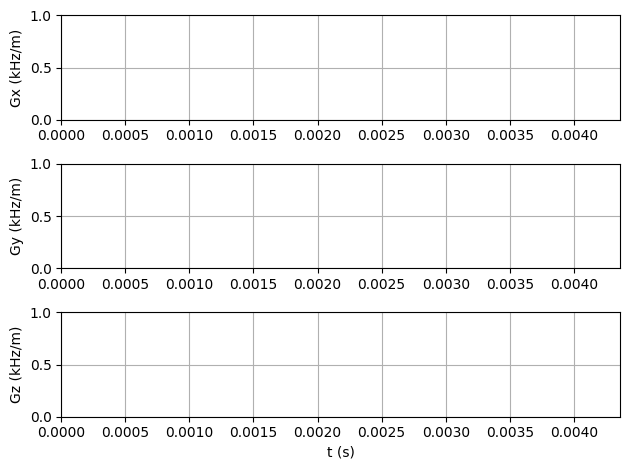

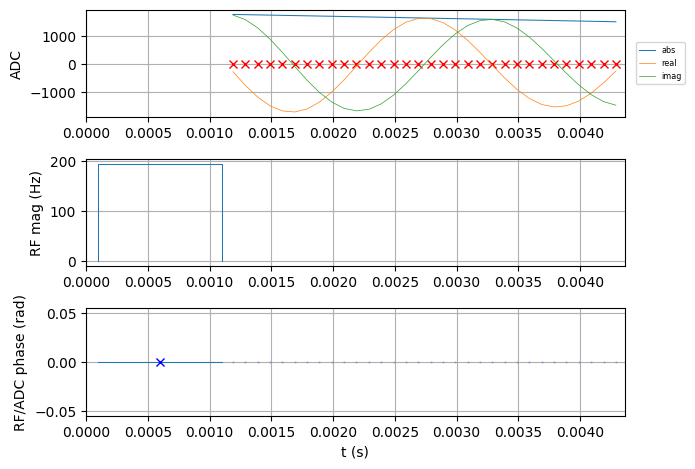

In [10]:
seq.plot(plot_now=False)
mr0.util.insert_signal_plot(seq=seq, signal=signal.numpy())
plt.show()

In [11]:
print('The maximum signal amplitude is {}'.format(np.max(np.abs(signal.numpy()))))

The maximum signal amplitude is 1765.160400390625


# Simulate FID with JEMRIS

In [12]:
iNump = psutil.cpu_count(logical=False)

os.chdir('FID')
subprocess.run(["mpirun", "-np", str(iNump), "pjemris", "simu.xml"])
os.chdir('..')


Parallel jemris 2.9.2 (b0b3084267c41df80e4799beb7378060a0b8f60d)

Model    : Bloch	  , solver = CVODE
Sample   : 2D sphere	  , spins  = 7825
TxArray  : /usr/local/share/jemris/matlab/uniform.xml
RxArray  : /usr/local/share/jemris/matlab/uniform.xml
Sequence : /Users/jfelder/Documents/python/juart-dev/notebooks/FID/FID.xml

Mac.fritz.box -> Master Process: send MR sample (7825 spins) to 11 slave(s)

Simulating | ************************************************** | 100% done

Actual simulation took 0.87 seconds.


In [13]:
shutil.copyfile( os.path.join( 'FID', 'signals_ismrmrd.h5'),  'signals_ismrmrd.h5')

'signals_ismrmrd.h5'

In [14]:
dset = ismrmrd.Dataset('signals_ismrmrd.h5', 'dataset', create_if_needed=False)

In [15]:
# extract the header
header = ismrmrd.xsd.CreateFromDocument(dset.read_xml_header())
enc = header.encoding[0]

# Matrix size
eNx = enc.encodedSpace.matrixSize.x
eNy = enc.encodedSpace.matrixSize.y
eNz = enc.encodedSpace.matrixSize.z
rNx = enc.reconSpace.matrixSize.x
rNy = enc.reconSpace.matrixSize.y
rNz = enc.reconSpace.matrixSize.z

if(header.acquisitionSystemInformation.systemVendor == 'JEMRIS'):
    # Adjust for JEMRIS double matrix size bug
    eNx = eNx // 2
    eNy = eNy // 2
    eNz = eNz // 2
    rNx = rNx // 2
    rNy = rNy // 2
    rNz = rNz // 2
    if(eNx==0):
        eNx = 1
    if(eNy==0):
        eNy = 1
    if(eNz==0):
        eNz = 1
    if(rNx==0):
        rNx = 1
    if(rNy==0):
        rNy = 1
    if(rNz==0):
        rNz = 1
        
# Field of View
eFOVx = enc.encodedSpace.fieldOfView_mm.x
eFOVy = enc.encodedSpace.fieldOfView_mm.y
eFOVz = enc.encodedSpace.fieldOfView_mm.z
rFOVx = enc.reconSpace.fieldOfView_mm.x
rFOVy = enc.reconSpace.fieldOfView_mm.y
rFOVz = enc.reconSpace.fieldOfView_mm.z

# Number of Slices, Reps, Contrasts, etc.
if header.acquisitionSystemInformation.receiverChannels != None:        # Attention: This flag is not handled correctly by JEMRIS. We will treat this later.
    ncoils = header.acquisitionSystemInformation.receiverChannels
else:
    ncoils = 1

if enc.encodingLimits.slice != None:
    nslices = enc.encodingLimits.slice.maximum + 1
else:
    nslices = 1

if enc.encodingLimits.repetition != None:
    nreps = enc.encodingLimits.repetition.maximum + 1
else:
    nreps = 1

if enc.encodingLimits.set != None:
    nsets = enc.encodingLimits.set.maximum + 1
else:
    nsets = 1

if enc.encodingLimits.contrast != None:
    ncontrasts = enc.encodingLimits.contrast.maximum + 1
else:
    ncontrasts = 1

print('Parameters dertermined from the raw data file:')
print('FOV (x,y,z) = {},{},{}'.format(rFOVx, rFOVy, rFOVz))
print('Encoding matrix size (x,y,z) = {},{},{}'.format(eNx, eNy, eNz))
print('Image matrix size (x,y,z) = {},{},{}'.format(rNx, rNy, rNz))
print('Number of coils = {}'.format(ncoils))
print('Number of slices = {}'.format(nslices))
print('Number of repetitions = {}'.format(nreps))
print('Number of sets = {}'.format(nsets))
print('Number of contrasts = {}'.format(ncontrasts))

Parameters dertermined from the raw data file:
FOV (x,y,z) = 200.0,200.0,5.0
Encoding matrix size (x,y,z) = 32,32,1
Image matrix size (x,y,z) = 32,32,1
Number of coils = 1
Number of slices = 1
Number of repetitions = 1
Number of sets = 1
Number of contrasts = 1


In [16]:
firstacq=0
for acqnum in range(dset.number_of_acquisitions()):

    acq = dset.read_acquisition(acqnum)
    
    # TODO: Currently ignoring noise scans
    if acq.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT):
        print("Found noise scan at acq ", acqnum)
        continue
    else:
        firstacq = acqnum
        print("Imaging acquisition starts at acq ", acqnum)
        break

print('Numer of imaging k-sapce lines in the acquistion is {}'.format(dset.number_of_acquisitions()-firstacq))

Imaging acquisition starts at acq  0
Numer of imaging k-sapce lines in the acquistion is 2


In [17]:
# Get number of lines from header
nlines = (dset.number_of_acquisitions()-firstacq-1) 

acq = dset.read_acquisition(firstacq+1)
nsamples = len(acq.data[0])

# We are expecting nsets * ncontrasts * eNy data sets // here eNy = 1 for the FID
nlines_expected = nsets * ncontrasts * 1

if nlines != nlines_expected:
    firstacq = nlines - nlines_expected
    nlines = nlines_expected
    print("Start of imaging acquisition adopted to ", firstacq)
    print('Numer of imaging k-sapce lines in the acquistion adopted to {}'.format(dset.number_of_acquisitions()-firstacq))

print('Number of qcquistion lines reduced to {}'.format(nlines))
print('Number of samples per line is {}'.format(nsamples))

Number of qcquistion lines reduced to 1
Number of samples per line is 32


In [18]:
acq = dset.read_acquisition(firstacq+1)
if np.ndim(acq.data) == 2:
    ncoils = acq.data.shape[0]
    if ncoils > 1:
        print('Receive coil array detected: \n\tThe header information for coil arrays is not set by JEMRIS, so that a coil array con only be detected using the k-spae data shape.')
        print('This data has {} receive channels. Adjusted ncoils accordingly.'.format(ncoils))

In [19]:
# preallocate storrage
all_data = np.zeros( (nlines, ncoils, nsamples), dtype=np.complex64 )
all_kspace = np.zeros( (nlines, nsamples, 3), dtype=np.complex64 )

# assign
for acqnum in range(firstacq + 1, dset.number_of_acquisitions()):
    acq = dset.read_acquisition(acqnum)
    all_data[acqnum-firstacq-1,:] = acq.data
    all_kspace[acqnum-firstacq-1,:,:] = acq.traj

In [20]:
print('The maximum signal amplitude is {}'.format(np.max(np.abs(np.squeeze(all_data)))))

The maximum signal amplitude is 0.9342243075370789


In [21]:
dset.close()